<a href="https://colab.research.google.com/github/sgsinghashka-del/-KNN-30-Practical-Sample/blob/main/KNN_30_Practical_Sample_IPYNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Salary Category Prediction (Experience, Salary)

===== Salary Category Prediction =====
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00         1
      Medium       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [0 0 1]]

Enter years of experience: 2
Enter salary: 20000

Predicted Salary Category: Low


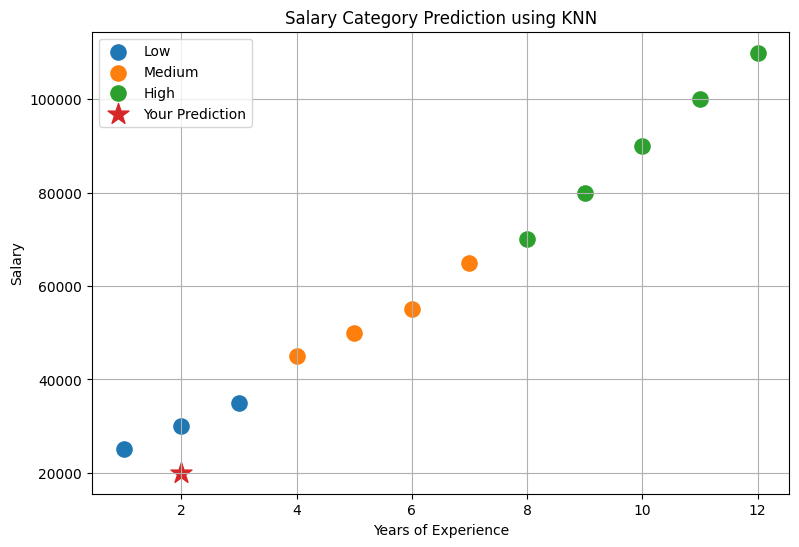

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("salary.csv")

# Features
X = data[["Experience", "Salary"]]

# Target
y = data["Category"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train model
model.fit(X_train_scaled, y_train)

# Test prediction
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("===== Salary Category Prediction =====")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# -----------------------------
# User Prediction
# -----------------------------

experience = float(input("\nEnter years of experience: "))
salary = float(input("Enter salary: "))

new_data = pd.DataFrame({
    "Experience": [experience],
    "Salary": [salary]
})

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPredicted Salary Category:", prediction[0])


# -----------------------------
# Graph
# -----------------------------

plt.figure(figsize=(9, 6))

# Plot each category separately
for category in ["Low", "Medium", "High"]:

    category_data = data[data["Category"] == category]

    plt.scatter(
        category_data["Experience"],
        category_data["Salary"],
        s=120,
        label=category
    )

# Plot user's prediction
plt.scatter(
    experience,
    salary,
    s=250,
    marker="*",
    label="Your Prediction"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Category Prediction using KNN")

plt.legend()
plt.grid(True)

plt.show()

2. Employee Promotion Prediction (Experience, Performance)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
 [[1 0]
 [0 2]]

Enter years of experience: 8
Enter performance score: 60


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Promotion Prediction: Yes
No: 0.00%
Yes: 100.00%


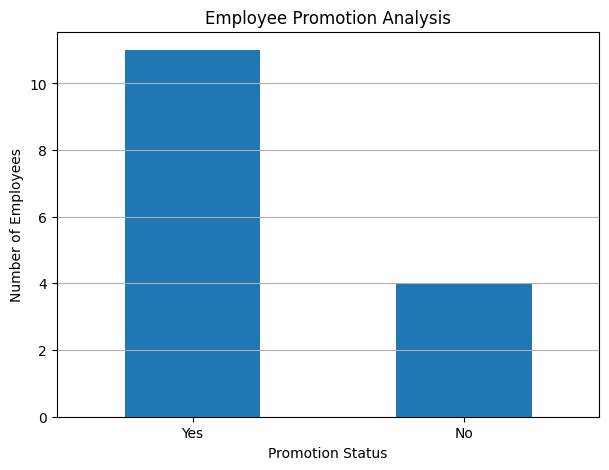

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("promotion.csv")

X = df[["Experience", "Performance"]]
y = df["Promotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# User input
exp = float(input("\nEnter years of experience: "))
perf = float(input("Enter performance score: "))

new = scaler.transform([[exp, perf]])

print("\nPromotion Prediction:", model.predict(new)[0])

for c, p in zip(model.classes_, model.predict_proba(new)[0]):
    print(f"{c}: {p*100:.2f}%")

# Different Graph - Bar Chart
df["Promotion"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Promotion Status")
plt.ylabel("Number of Employees")
plt.title("Employee Promotion Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

3. Student Result Prediction (Pass / Fail)

Accuracy: 1.0

Enter study hours: 9
Enter attendance: 50


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Student Result: Fail


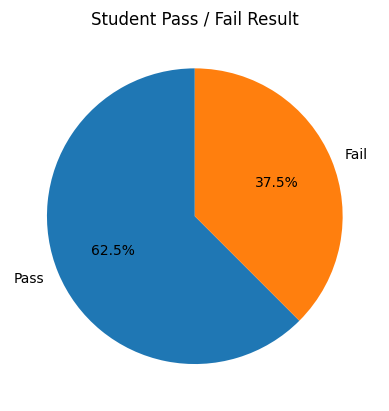

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("student.csv")

X = df[["StudyHours", "Attendance"]]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# Student input
hours = float(input("\nEnter study hours: "))
attendance = float(input("Enter attendance: "))

result = model.predict([[hours, attendance]])

print("Student Result:", result[0])

# Pie Chart
df["Result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Pass / Fail Result")
plt.ylabel("")
plt.show()

4. Loan Approval System

Accuracy: 1.0

Enter income: 50000
Enter credit score: 550
Loan Approval: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


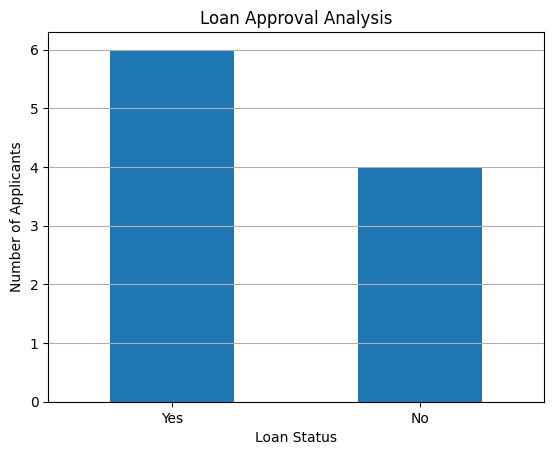

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv("loan.csv")

X = df[["Income", "CreditScore"]]
y = df["Loan"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# User input
income = float(input("\nEnter income: "))
credit = float(input("Enter credit score: "))

result = model.predict(
    scaler.transform([[income, credit]])
)

print("Loan Approval:", result[0])

# Bar Graph
df["Loan"].value_counts().plot(kind="bar")

plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

5. Credit Card Fraud Detection

Accuracy: 1.0

Enter transaction amount: 100000
Enter transaction time: 10


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Transaction: Yes


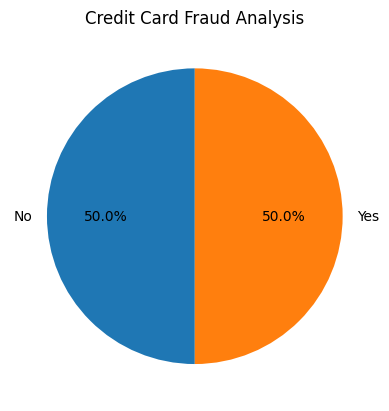

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv("fraud.csv")

X = df[["Amount", "Time"]]
y = df["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# User input
amount = float(input("\nEnter transaction amount: "))
time = float(input("Enter transaction time: "))

result = model.predict(
    scaler.transform([[amount, time]])
)

print("Transaction:", result[0])

# Pie Chart
df["Fraud"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Credit Card Fraud Analysis")
plt.ylabel("")
plt.show()

6. Medical Diagnosis (Diabetes Yes/No) ( Sugar, BP )

Accuracy: 1.0

Enter sugar level: 340
Enter BP: 240
Diabetes Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


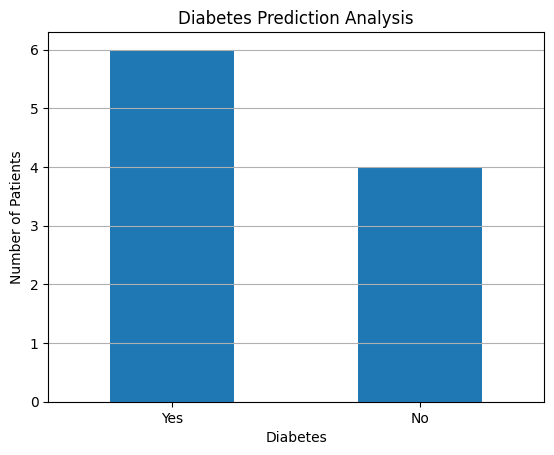

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv("diabetes.csv")

X = df[["Sugar", "BP"]]
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# User input
sugar = float(input("\nEnter sugar level: "))
bp = float(input("Enter BP: "))

result = model.predict(
    scaler.transform([[sugar, bp]])
)

print("Diabetes Prediction:", result[0])

# Bar Graph
df["Diabetes"].value_counts().plot(kind="bar")

plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")
plt.title("Diabetes Prediction Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

7. Customer Churn Prediction (Years, Usage)

Accuracy: 1.0

Enter customer years: 5
Enter usage: 5
Customer Churn Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


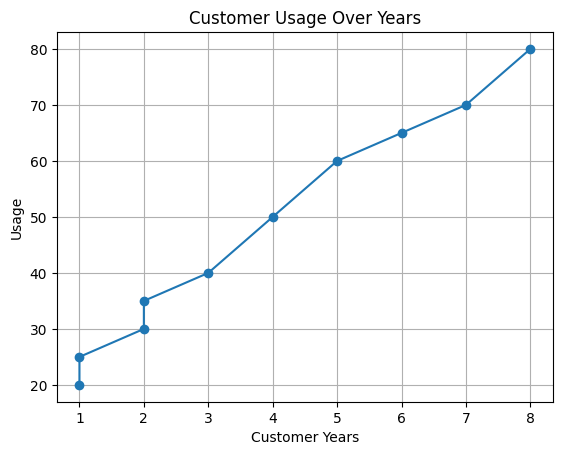

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv("churn.csv")

X = df[["Years", "Usage"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# User input
years = float(input("\nEnter customer years: "))
usage = float(input("Enter usage: "))

result = model.predict(
    scaler.transform([[years, usage]])
)

print("Customer Churn Prediction:", result[0])

# Line Graph
plt.plot(df["Years"], df["Usage"], marker="o")

plt.xlabel("Customer Years")
plt.ylabel("Usage")
plt.title("Customer Usage Over Years")
plt.grid()
plt.show()

8. Email Spam Detection (Number of Links )

Accuracy: 1.0

Enter number of links: 10
Email Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


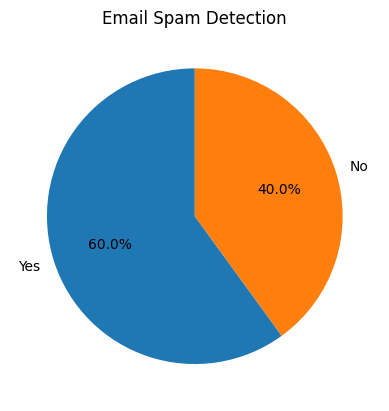

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("spam.csv")

X = df[["Links"]]
y = df["Spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# User input
links = float(input("\nEnter number of links: "))

result = model.predict([[links]])

print("Email Prediction:", result[0])

# Pie Chart
df["Spam"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Email Spam Detection")
plt.ylabel("")
plt.show()

9. Movie Recommendation ( Rating)

Enter movie rating: 2.5
Movie Recommendation: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


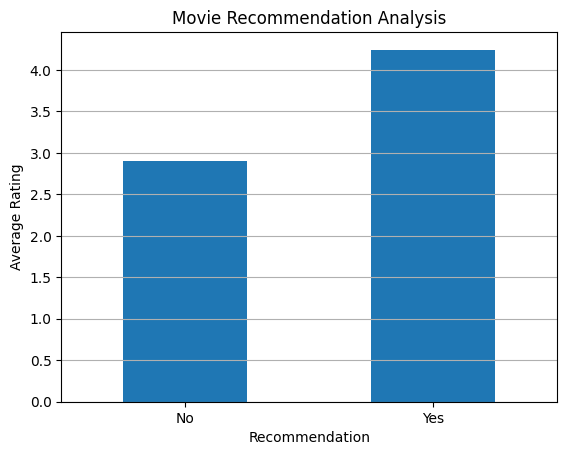

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("movies.csv")

X = df[["Rating"]]
y = df["Recommend"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

rating = float(input("Enter movie rating: "))

result = model.predict([[rating]])

print("Movie Recommendation:", result[0])

# Bar Graph
df.groupby("Recommend")["Rating"].mean().plot(kind="bar")

plt.xlabel("Recommendation")
plt.ylabel("Average Rating")
plt.title("Movie Recommendation Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

10. House Category Prediction (Cheap / Expensive)

Enter house area: 1180
Enter house price: 6000000
House Category: Expensive


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


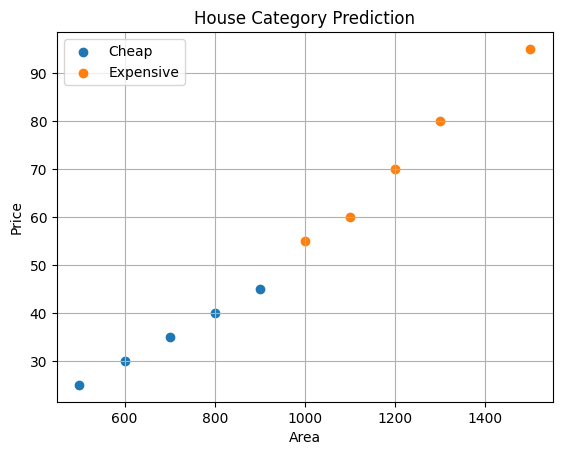

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("house.csv")

X = df[["Area", "Price"]]
y = df["Category"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

area = float(input("Enter house area: "))
price = float(input("Enter house price: "))

result = model.predict([[area, price]])

print("House Category:", result[0])

# Scatter Graph
for category in df["Category"].unique():
    d = df[df["Category"] == category]
    plt.scatter(d["Area"], d["Price"], label=category)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Category Prediction")
plt.legend()
plt.grid()
plt.show()

11. Weather Prediction (Temp, Humidity)

Enter temperature: 55
Enter humidity: 90


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Weather Prediction: Rainy


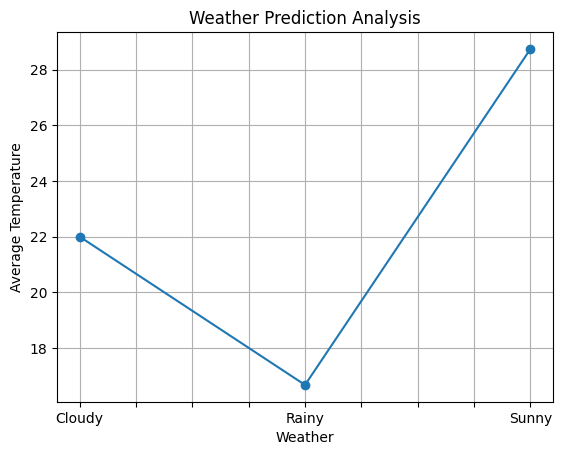

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("weather.csv")

X = df[["Temperature", "Humidity"]]
y = df["Weather"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

temp = float(input("Enter temperature: "))
humidity = float(input("Enter humidity: "))

result = model.predict([[temp, humidity]])

print("Weather Prediction:", result[0])

# Line Graph
df.groupby("Weather")["Temperature"].mean().plot(kind="line", marker="o")

plt.xlabel("Weather")
plt.ylabel("Average Temperature")
plt.title("Weather Prediction Analysis")
plt.grid()
plt.show()

12. Heart Disease Prediction ( Age, BP )

Enter age: 86
Enter BP: 250
Heart Disease Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


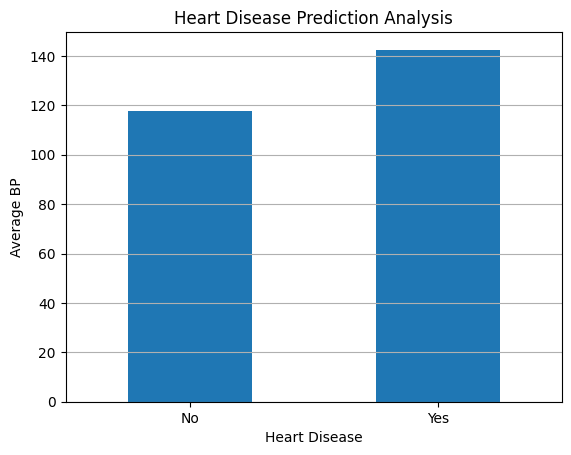

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("heart.csv")

X = df[["Age", "BP"]]
y = df["HeartDisease"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
bp = float(input("Enter BP: "))

result = model.predict([[age, bp]])

print("Heart Disease Prediction:", result[0])

# Bar Graph
df.groupby("HeartDisease")["BP"].mean().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Average BP")
plt.title("Heart Disease Prediction Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

13. Mobile Price Range Classification

Enter RAM (GB): 2
Enter Storage (GB): 4
Mobile Price Range: Low


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


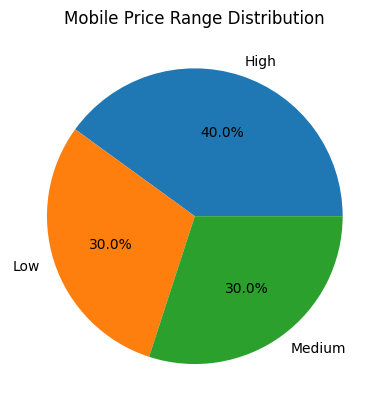

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("mobile.csv")

X = df[["RAM", "Storage"]]
y = df["PriceRange"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

ram = float(input("Enter RAM (GB): "))
storage = float(input("Enter Storage (GB): "))

result = model.predict([[ram, storage]])

print("Mobile Price Range:", result[0])

# Pie Chart
df["PriceRange"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Mobile Price Range Distribution")
plt.ylabel("")
plt.show()


14. Student Admission Prediction

Enter marks: 35
Enter attendance: 12
Admission Prediction: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


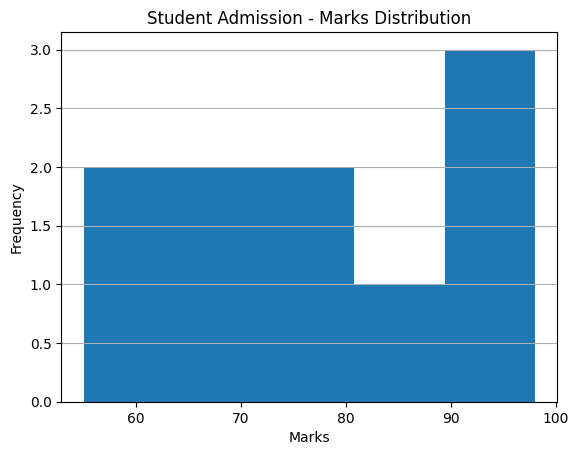

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("admission.csv")

X = df[["Marks", "Attendance"]]
y = df["Admission"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

marks = float(input("Enter marks: "))
attendance = float(input("Enter attendance: "))

result = model.predict([[marks, attendance]])

print("Admission Prediction:", result[0])

# Histogram
df["Marks"].plot(kind="hist", bins=5)

plt.xlabel("Marks")
plt.title("Student Admission - Marks Distribution")
plt.grid(axis="y")
plt.show()

15. Job Recommendation (IT / Non-IT)

Enter skill level: 6
Enter experience: 4
Job Recommendation: IT


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


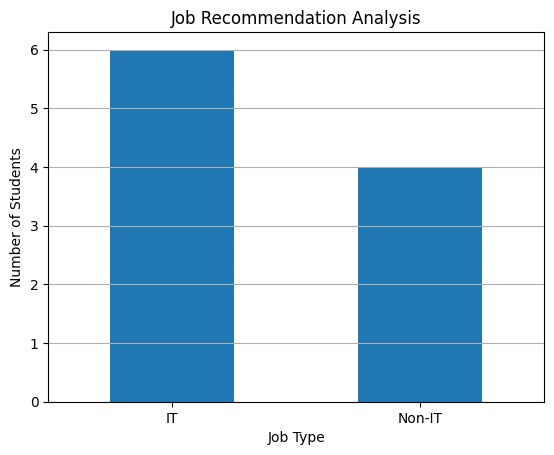

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("job.csv")

X = df[["Skills", "Experience"]]
y = df["JobType"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

skills = float(input("Enter skill level: "))
experience = float(input("Enter experience: "))

result = model.predict([[skills, experience]])

print("Job Recommendation:", result[0])

# Bar Graph
df["JobType"].value_counts().plot(kind="bar")

plt.xlabel("Job Type")
plt.ylabel("Number of Students")
plt.title("Job Recommendation Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

16. Online Shopping Purchase Prediction

Enter age: 25
Enter time spent (minutes): 60
Purchase Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


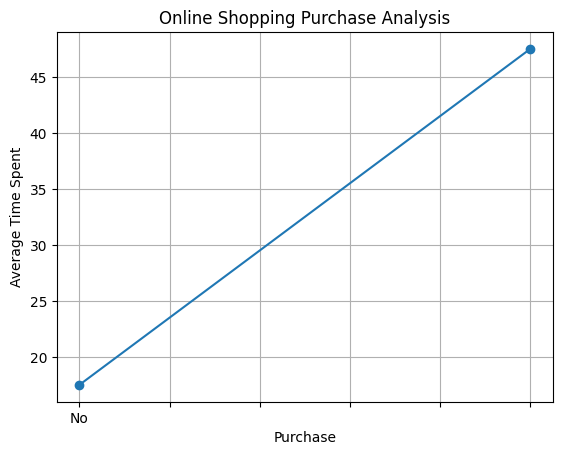

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("shopping.csv")

X = df[["Age", "TimeSpent"]]
y = df["Purchase"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
time = float(input("Enter time spent (minutes): "))

result = model.predict([[age, time]])

print("Purchase Prediction:", result[0])

# Line Graph
df.groupby("Purchase")["TimeSpent"].mean().plot(
    kind="line", marker="o"
)

plt.xlabel("Purchase")
plt.ylabel("Average Time Spent")
plt.title("Online Shopping Purchase Analysis")
plt.grid()
plt.show()

17. Employee Attrition Prediction

Enter age: 35
Enter experience: 6
Employee Attrition Prediction: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


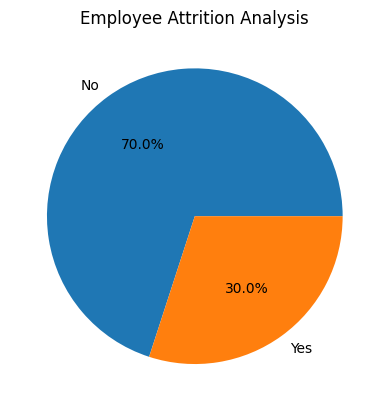

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("attrition.csv")

X = df[["Age", "Experience"]]
y = df["Attrition"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
experience = float(input("Enter experience: "))

result = model.predict([[age, experience]])

print("Employee Attrition Prediction:", result[0])

# Pie Chart
df["Attrition"].value_counts().plot(
    kind="pie", autopct="%1.1f%%"
)

plt.title("Employee Attrition Analysis")
plt.ylabel("")
plt.show()

18. Traffic Condition Prediction

Enter number of vehicles: 89
Enter average speed: 50
Traffic Condition: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


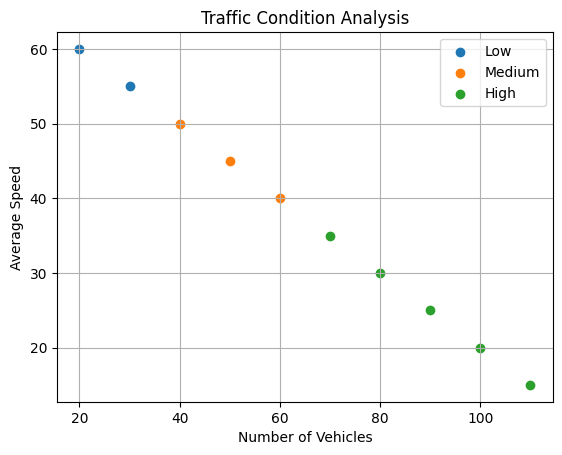

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("traffic.csv")

X = df[["Vehicles", "Speed"]]
y = df["Traffic"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

vehicles = float(input("Enter number of vehicles: "))
speed = float(input("Enter average speed: "))

result = model.predict([[vehicles, speed]])

print("Traffic Condition:", result[0])

# Scatter Graph
for traffic in df["Traffic"].unique():
    d = df[df["Traffic"] == traffic]
    plt.scatter(d["Vehicles"], d["Speed"], label=traffic)

plt.xlabel("Number of Vehicles")
plt.ylabel("Average Speed")
plt.title("Traffic Condition Analysis")
plt.legend()
plt.grid()
plt.show()


19. Insurance Claim Prediction

Enter age: 86
Enter claim amount: 6000000
Insurance Claim Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


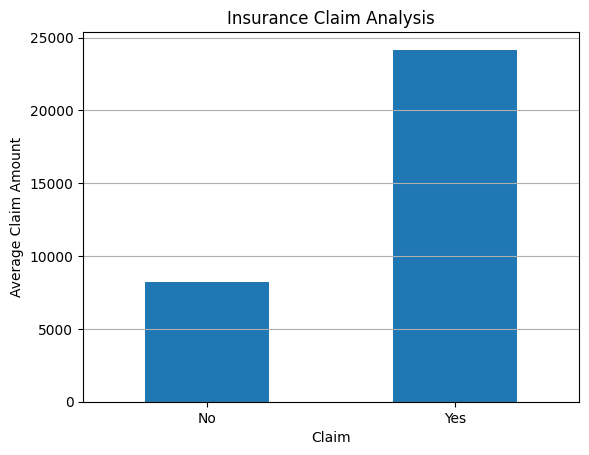

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("insurance.csv")

X = df[["Age", "ClaimAmount"]]
y = df["Claim"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
amount = float(input("Enter claim amount: "))

result = model.predict([[age, amount]])

print("Insurance Claim Prediction:", result[0])

# Bar Graph
df.groupby("Claim")["ClaimAmount"].mean().plot(kind="bar")

plt.xlabel("Claim")
plt.ylabel("Average Claim Amount")
plt.title("Insurance Claim Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

20. Disease Risk Level

Enter age: 65
Enter BP: 250
Disease Risk Level: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


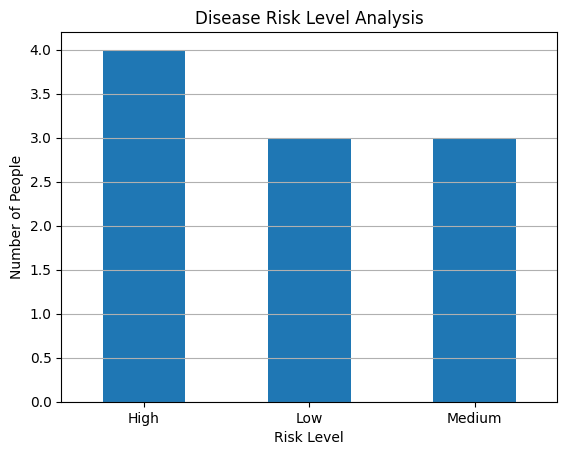

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("disease_risk.csv")

X = df[["Age", "BP"]]
y = df["Risk"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
bp = float(input("Enter BP: "))

result = model.predict([[age, bp]])

print("Disease Risk Level:", result[0])

# Bar Graph
df["Risk"].value_counts().plot(kind="bar")

plt.xlabel("Risk Level")
plt.ylabel("Number of People")
plt.title("Disease Risk Level Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

21. Product Quality Check

Enter number of defects: 5
Enter quality score: 56
Product Quality: Bad


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


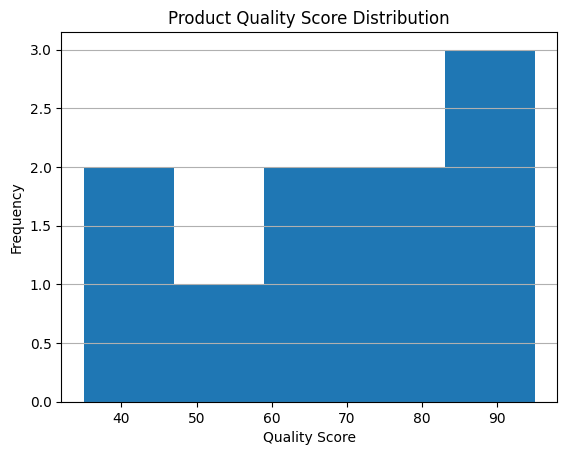

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("quality.csv")

X = df[["DefectCount", "QualityScore"]]
y = df["Quality"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

defects = float(input("Enter number of defects: "))
score = float(input("Enter quality score: "))

result = model.predict([[defects, score]])

print("Product Quality:", result[0])

# Histogram
df["QualityScore"].plot(kind="hist", bins=5)

plt.xlabel("Quality Score")
plt.title("Product Quality Score Distribution")
plt.grid(axis="y")
plt.show()

22. College Branch Allocation

Enter marks: 78
Enter preference score: 60
College Branch: Commerce


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


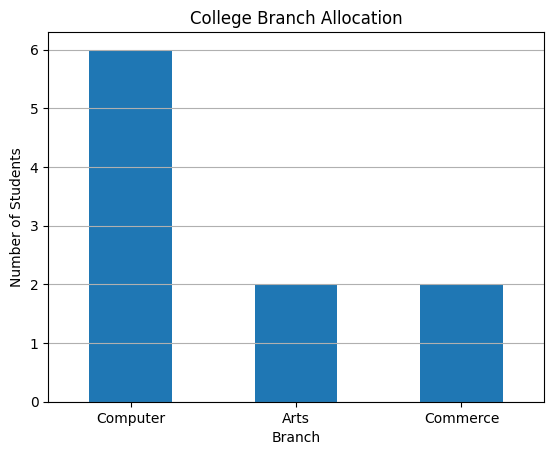

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("college.csv")

X = df[["Marks", "PreferenceScore"]]
y = df["Branch"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

marks = float(input("Enter marks: "))
preference = float(input("Enter preference score: "))

result = model.predict([[marks, preference]])

print("College Branch:", result[0])

# Bar Graph
df["Branch"].value_counts().plot(kind="bar")

plt.xlabel("Branch")
plt.ylabel("Number of Students")
plt.title("College Branch Allocation")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

23. Employee Performance Rating

Enter experience: 5
Enter performance score: 63
Employee Performance Rating: Average


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


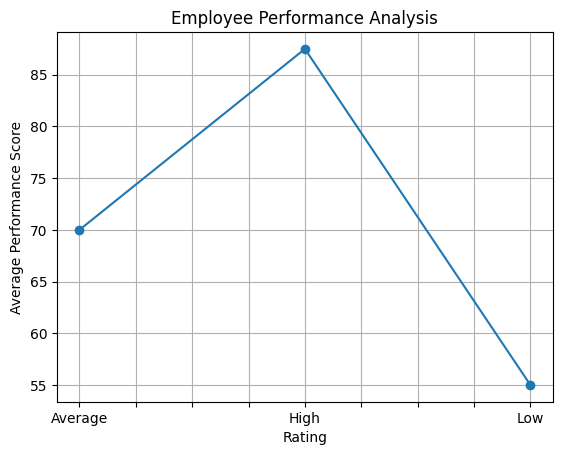

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("performance.csv")

X = df[["Experience", "PerformanceScore"]]
y = df["Rating"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

experience = float(input("Enter experience: "))
score = float(input("Enter performance score: "))

result = model.predict([[experience, score]])

print("Employee Performance Rating:", result[0])

# Line Graph
df.groupby("Rating")["PerformanceScore"].mean().plot(
    kind="line", marker="o"
)

plt.xlabel("Rating")
plt.ylabel("Average Performance Score")
plt.title("Employee Performance Analysis")
plt.grid()
plt.show()

24. Customer Satisfaction Prediction

Enter customer rating: 5
Enter service time: 5
Customer Satisfaction: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


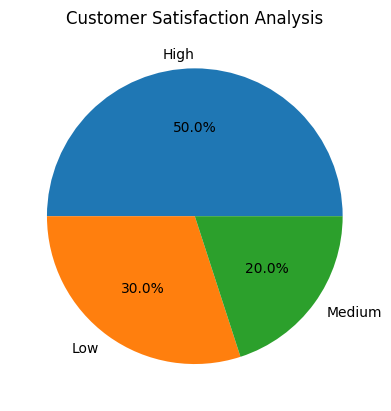

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("satisfaction.csv")

X = df[["Rating", "ServiceTime"]]
y = df["Satisfaction"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

rating = float(input("Enter customer rating: "))
time = float(input("Enter service time: "))

result = model.predict([[rating, time]])

print("Customer Satisfaction:", result[0])

# Pie Chart
df["Satisfaction"].value_counts().plot(
    kind="pie", autopct="%1.1f%%"
)

plt.title("Customer Satisfaction Analysis")
plt.ylabel("")
plt.show()

25. Attendance-Based Result Prediction

Enter attendance (%): 50
Enter study hours: 2
Result Prediction: Fail


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


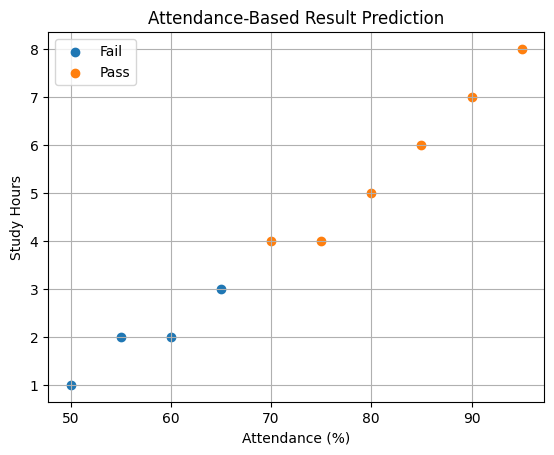

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("attendance.csv")

X = df[["Attendance", "StudyHours"]]
y = df["Result"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

attendance = float(input("Enter attendance (%): "))
hours = float(input("Enter study hours: "))

result = model.predict([[attendance, hours]])

print("Result Prediction:", result[0])

# Scatter Graph
for result in df["Result"].unique():
    d = df[df["Result"] == result]
    plt.scatter(d["Attendance"], d["StudyHours"], label=result)

plt.xlabel("Attendance (%)")
plt.ylabel("Study Hours")
plt.title("Attendance-Based Result Prediction")
plt.legend()
plt.grid()
plt.show()

26. Disease Severity Prediction

Enter age: 52
Enter symptom score: 6
Disease Severity: Severe


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


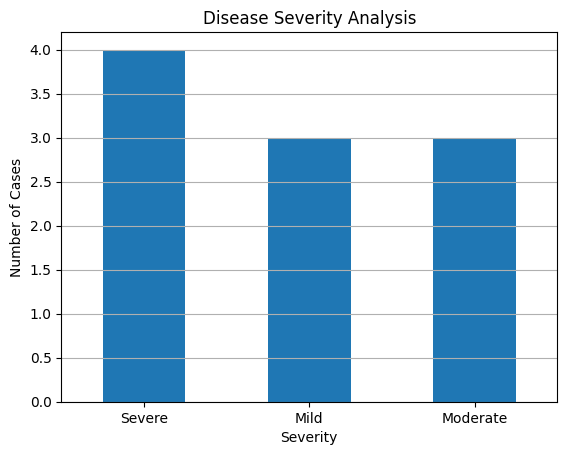

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("severity.csv")

X = df[["Age", "SymptomScore"]]
y = df["Severity"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
symptoms = float(input("Enter symptom score: "))

result = model.predict([[age, symptoms]])

print("Disease Severity:", result[0])

# Bar Graph
df["Severity"].value_counts().plot(kind="bar")

plt.xlabel("Severity")
plt.ylabel("Number of Cases")
plt.title("Disease Severity Analysis")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

27. Internet Usage Category

Enter internet usage hours: 3
Enter data used (GB): 2
Internet Usage Category: Low


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


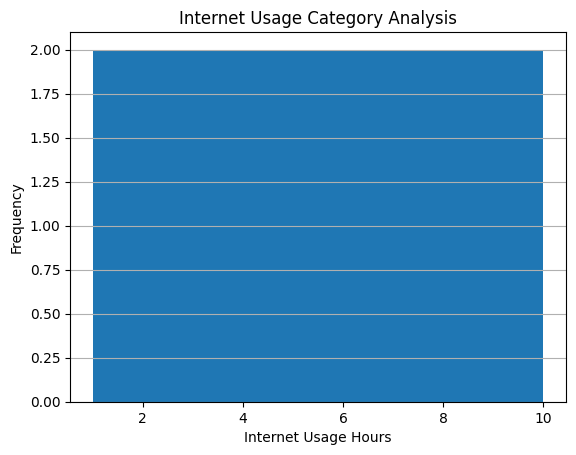

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("internet.csv")

X = df[["HoursPerDay", "DataGB"]]
y = df["Usage"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

hours = float(input("Enter internet usage hours: "))
data = float(input("Enter data used (GB): "))

result = model.predict([[hours, data]])

print("Internet Usage Category:", result[0])

# Histogram
df["HoursPerDay"].plot(kind="hist", bins=5)

plt.xlabel("Internet Usage Hours")
plt.title("Internet Usage Category Analysis")
plt.grid(axis="y")
plt.show()

28. Bank Customer Risk Category ( Age, Income )

Enter age: 26
Enter income: 30000


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Bank Customer Risk: Medium


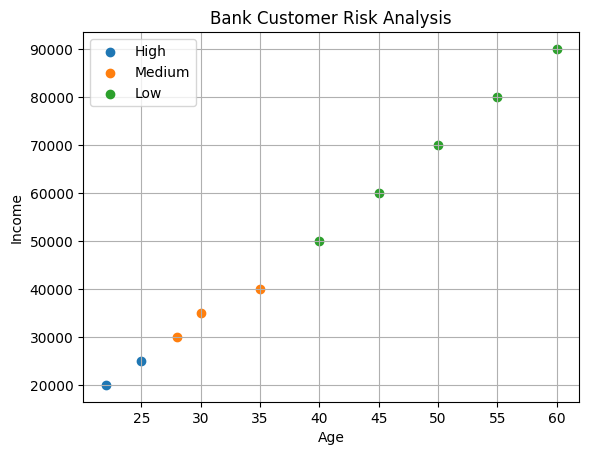

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("bank_risk.csv")

X = df[["Age", "Income"]]
y = df["Risk"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

age = float(input("Enter age: "))
income = float(input("Enter income: "))

result = model.predict([[age, income]])

print("Bank Customer Risk:", result[0])

# Scatter Graph
for risk in df["Risk"].unique():
    d = df[df["Risk"] == risk]
    plt.scatter(d["Age"], d["Income"], label=risk)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Bank Customer Risk Analysis")
plt.legend()
plt.grid()
plt.show()

29. Vehicle Type Classification  (Wheels, Engine power)

Enter number of wheels: 3
Enter engine power: 50
Vehicle Type: Auto


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


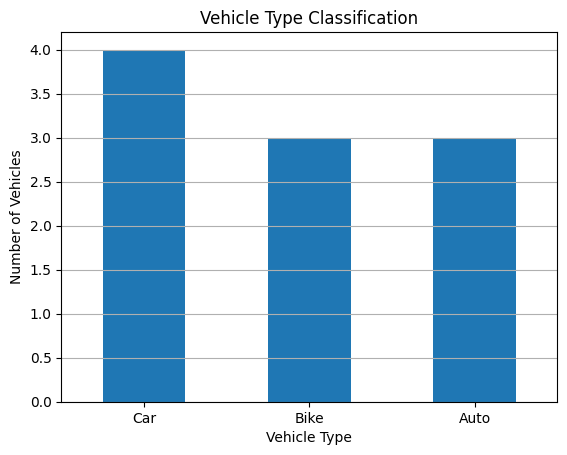

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("vehicle.csv")

X = df[["Wheels", "EnginePower"]]
y = df["VehicleType"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

wheels = float(input("Enter number of wheels: "))
power = float(input("Enter engine power: "))

result = model.predict([[wheels, power]])

print("Vehicle Type:", result[0])

# Bar Graph
df["VehicleType"].value_counts().plot(kind="bar")

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles")
plt.title("Vehicle Type Classification")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


30. E-commerce User Type ( Purchases Month)

Enter purchases per month: 03
E-commerce User Type: Occasional


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


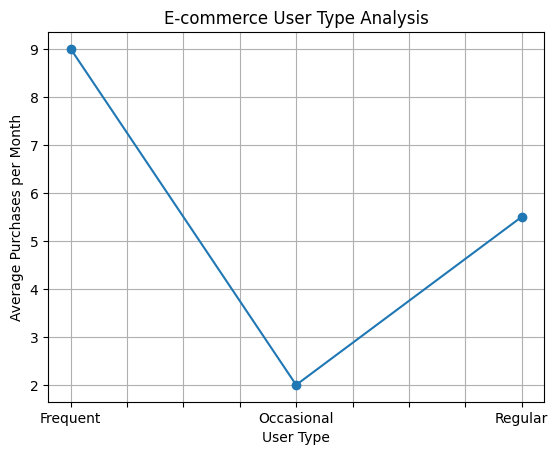

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("ecommerce.csv")

X = df[["PurchasesPerMonth"]]
y = df["UserType"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

purchases = float(input("Enter purchases per month: "))

result = model.predict([[purchases]])

print("E-commerce User Type:", result[0])

# Line Graph
df.groupby("UserType")["PurchasesPerMonth"].mean().plot(
    kind="line", marker="o"
)

plt.xlabel("User Type")
plt.ylabel("Average Purchases per Month")
plt.title("E-commerce User Type Analysis")
plt.grid()
plt.show()